In [1]:
import pandas as pd
import numpy as np

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [23]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

In [2]:
#النتائج ستكون ثابتة في كل مرة تشغّل فيها الكود.
RANDOM_STATE = 42

In [7]:
df = pd.read_csv('./student-mat.csv', sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [8]:
# العملية 0 
print("شكل البيانات (rows, cols):", df.shape)

شكل البيانات (rows, cols): (395, 33)


In [27]:
print("\nتوزيع الطلاب حسب school و sex:")
display(pd.crosstab(df['school'], df['sex']))


توزيع الطلاب حسب school و sex:


sex,F,M
school,,
GP,183,166
MS,25,21


In [9]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

None

<Axes: xlabel='G1', ylabel='Count'>

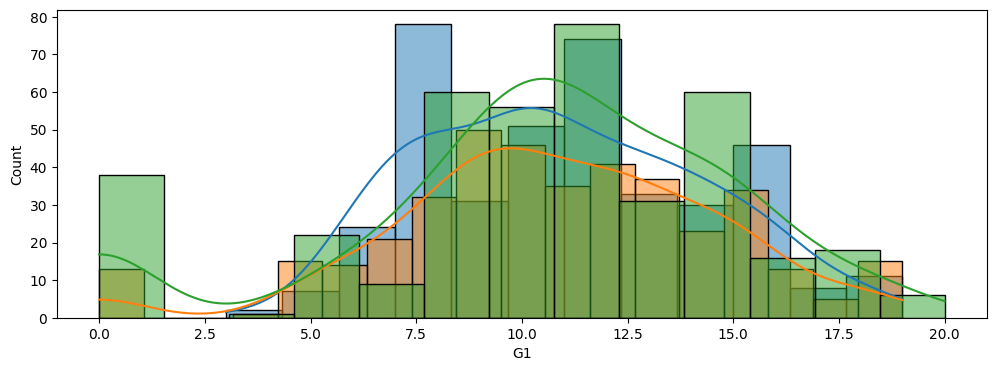

In [28]:
plt.figure(figsize=(12,4))
sns.histplot(df['G1'], kde=True)
sns.histplot(df['G2'], kde=True)
sns.histplot(df['G3'], kde=True)

In [29]:
df[['G1','G2','G3']].describe()


,G1,G2,G3
count,395.000000,395.000000,395.000000
mean,10.908861,10.713924,10.415190
std,3.319195,3.761505,4.581443
min,3.000000,0.000000,0.000000
25%,8.000000,9.000000,8.000000
50%,11.000000,11.000000,11.000000
75%,13.000000,13.000000,14.000000
max,19.000000,19.000000,20.000000


In [30]:
for sup in ['schoolsup','famsup']:
    if sup in df.columns:
        print(f"\nتأثير {sup} على G3:")
        display(df.groupby(sup)['G3'].describe())


تأثير schoolsup على G3:


,count,mean,std,min,25%,50%,75%,max
schoolsup,,,,,,,,
no,344.0,10.561047,4.769533,0.0,9.0,11.0,14.0,20.0
yes,51.0,9.431373,2.865344,0.0,8.0,10.0,11.0,17.0



تأثير famsup على G3:


,count,mean,std,min,25%,50%,75%,max
famsup,,,,,,,,
no,153.0,10.640523,4.636262,0.0,9.0,11.0,14.0,20.0
yes,242.0,10.272727,4.550318,0.0,8.0,11.0,13.0,19.0


Correlation absences-G3: 0.03424731615006934


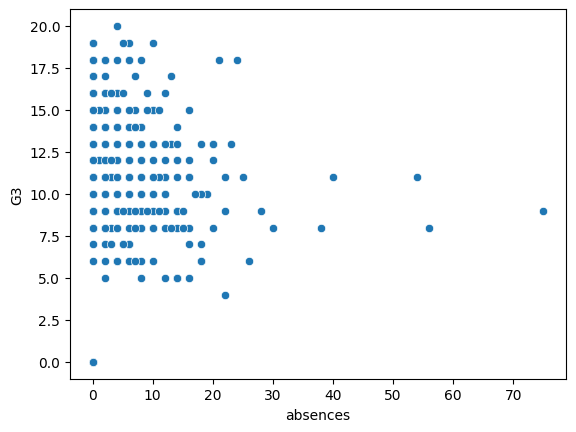

In [31]:
sns.scatterplot(x='absences', y='G3', data=df)
print("Correlation absences-G3:", df['absences'].corr(df['G3']))

In [32]:
print("\nمتوسط G3 حسب الجنس:")
display(df.groupby('sex')['G3'].describe())

if 'address' in df.columns:
    display(df.groupby('address')['G3'].describe())


متوسط G3 حسب الجنس:


,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
F,208.0,9.966346,4.622338,0.0,8.0,10.0,13.0,19.0
M,187.0,10.914439,4.495297,0.0,9.0,11.0,14.0,20.0


,count,mean,std,min,25%,50%,75%,max
address,,,,,,,,
R,88.0,9.511364,4.556149,0.0,7.0,10.0,12.0,19.0
U,307.0,10.674267,4.563075,0.0,9.0,11.0,14.0,20.0


In [ ]:
#عرض ملخص إحصائي شامل لجميع الأعمدة في DataFrame df 
display(df.describe(include='all'))

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395,395,395.000000,395,395,395,395.000000,395.000000,395,395,...,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
unique,2,2,NaN,2,2,2,NaN,NaN,5,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,GP,F,NaN,U,GT3,T,NaN,NaN,other,other,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,349,208,NaN,307,281,354,NaN,NaN,141,217,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,16.696203,NaN,NaN,NaN,2.749367,2.521519,NaN,NaN,...,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,NaN,NaN,1.276043,NaN,NaN,NaN,1.094735,1.088201,NaN,NaN,...,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,NaN,NaN,15.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,NaN,NaN,16.000000,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN,...,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,NaN,NaN,17.000000,NaN,NaN,NaN,3.000000,2.000000,NaN,NaN,...,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,NaN,NaN,18.000000,NaN,NaN,NaN,4.000000,3.000000,NaN,NaN,...,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000


In [11]:
print("\nأسماء الأعمدة وأنواعها:")
print(df.dtypes)


أسماء الأعمدة وأنواعها:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object


In [12]:
print("\nالقيم المفقودة لكل عمود:")
print(df.isnull().sum())


القيم المفقودة لكل عمود:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [13]:
for c in ['G1','G2','G3','age','absences']:
    if df[c].dtype == 'object':
        df[c] = pd.to_numeric(df[c], errors='coerce')

In [14]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [15]:
df.loc[df['G1'] < 0, 'G1'] = np.nan
df.loc[df['G2'] < 0, 'G2'] = np.nan
df.loc[df['G3'] < 0, 'G3'] = np.nan

In [16]:
df.loc[df['G1'] > 20, 'G1'] = np.nan
df.loc[df['G2'] > 20, 'G2'] = np.nan
df.loc[df['G3'] > 20, 'G3'] = np.nan

In [17]:
df.loc[(df['age'] < 10) | (df['age'] > 100), 'age'] = np.nan


In [18]:
df.loc[df['absences'] < 0, 'absences'] = np.nan

In [ ]:
#تقسيم الاعمدة الرقمية و النصية 
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

In [ ]:
#مل القيم الفارغة في الاعمدة كل بحسب 
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

In [58]:
df[num_cols] = num_imputer.fit_transform(df[num_cols])
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [26]:
print("\nبعد المعالجة، القيم المفقودة لكل عمود:")
print(df.isnull().sum())


بعد المعالجة، القيم المفقودة لكل عمود:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


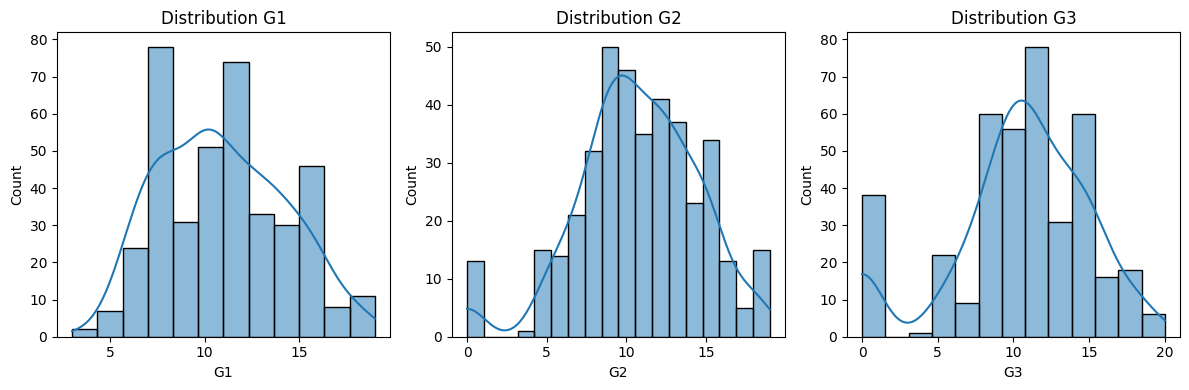

In [33]:
# 6. EDA مختصر (توزيعات ومقارنات)
# -------------------------
# توزيعات الدرجات
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
sns.histplot(df['G1'], kde=True)
plt.title('Distribution G1')
plt.subplot(1,3,2)
sns.histplot(df['G2'], kde=True)
plt.title('Distribution G2')
plt.subplot(1,3,3)
sns.histplot(df['G3'], kde=True)
plt.title('Distribution G3')
plt.tight_layout()
plt.show()

In [ ]:
# عشرة إحصائيات: mean per gender / school
# print("\nمتوسط G3 حسب الجنس:")
# display(df.groupby('sex')['G3'].describe())
# print("\nتوزيع الطلاب حسب school و sex:")
# display(pd.crosstab(df['school'], df['sex']))


متوسط G3 حسب الجنس:


,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
F,208.0,9.966346,4.622338,0.0,8.0,10.0,13.0,19.0
M,187.0,10.914439,4.495297,0.0,9.0,11.0,14.0,20.0



توزيع الطلاب حسب school و sex:


sex,F,M
school,,
GP,183,166
MS,25,21


In [ ]:
# if 'address' in df.columns:
#     display(df.groupby('address')['G3'].describe())

,count,mean,std,min,25%,50%,75%,max
address,,,,,,,,
R,88.0,9.511364,4.556149,0.0,7.0,10.0,12.0,19.0
U,307.0,10.674267,4.563075,0.0,9.0,11.0,14.0,20.0


In [ ]:
# for sup in ['schoolsup','famsup']:
#     if sup in df.columns:
#         print(f"\nتأثير {sup} على G3:")
#         display(df.groupby(sup)['G3'].describe())


تأثير schoolsup على G3:


,count,mean,std,min,25%,50%,75%,max
schoolsup,,,,,,,,
no,344.0,10.561047,4.769533,0.0,9.0,11.0,14.0,20.0
yes,51.0,9.431373,2.865344,0.0,8.0,10.0,11.0,17.0



تأثير famsup على G3:


,count,mean,std,min,25%,50%,75%,max
famsup,,,,,,,,
no,153.0,10.640523,4.636262,0.0,9.0,11.0,14.0,20.0
yes,242.0,10.272727,4.550318,0.0,8.0,11.0,13.0,19.0


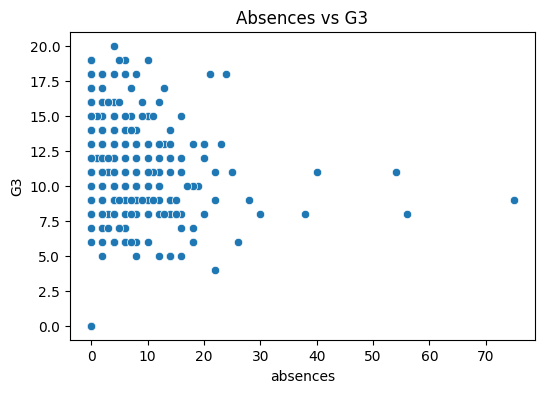

Correlation absences-G3: 0.03424731615006934


In [ ]:
# plt.figure(figsize=(6,4))
# sns.scatterplot(x='absences', y='G3', data=df)
# plt.title('Absences vs G3')
# plt.show()
# print("Correlation absences-G3:", df['absences'].corr(df['G3']))

In [38]:
# 7.1 Prepare features: تحويل الفئات لنماذج (one-hot)
features_class = ['studytime','failures','absences','schoolsup','famsup','internet','health','G1','G2']
# تأكد من وجود الأعمدة، وإضافة fallback إن لزم
features_class = [c for c in features_class if c in df.columns]

In [39]:
# Encode الفئات الثنائية (yes/no) إلى 0/1:
binary_map = {'yes':1, 'no':0, 'Y':1, 'N':0, 'U':1, 'R':0}
for c in ['schoolsup','famsup','internet']:
    if c in df.columns:
        df[c] = df[c].map({'yes':1,'no':0}).fillna(df[c])

In [40]:
df['perf_cat'] = pd.cut(df['G3'], bins=[-1,11,15,20], labels=['Poor','Good','Excellent'])

In [41]:
X = df[features_class].copy()
# تحويل أي أعمدة غير رقمية في X إلى رقمية (مثال schoolsup قد بدا رقمياً الآن)
X = pd.get_dummies(X, drop_first=True)
y = df['perf_cat']

In [ ]:
#لتقسيم البيانات إلى مجموعة تدريب و مجموعة اختبار.
#ف: تدريب النموذج على جزء من البيانات، ثم اختبار أدائه على جزء آخر لم يُرَ أثناء التدريب.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)


In [ ]:
# انشاء النموذج 
clf = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200)
clf.fit(X_train, y_train)
#توقع الفئة من كل مجموعة من البيانات
y_pred = clf.predict(X_test)
print("\nClassification report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


Classification report:
              precision    recall  f1-score   support

   Excellent       0.71      0.62      0.67         8
        Good       0.68      0.79      0.73        24
        Poor       0.93      0.87      0.90        47

    accuracy                           0.82        79
   macro avg       0.77      0.76      0.77        79
weighted avg       0.83      0.82      0.83        79

Accuracy: 0.8227848101265823
Confusion matrix:
 [[ 5  3  0]
 [ 2 19  3]
 [ 0  6 41]]


In [44]:
# 7.2 Regression (Predict G3)
features_reg = ['G1','G2','studytime','absences','failures','Dalc','Walc','health']
features_reg = [c for c in features_reg if c in df.columns]
Xr = df[features_reg]
yr = df['G3']

In [45]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=RANDOM_STATE)

In [46]:
# Linear Regression
lr = LinearRegression()
lr.fit(Xr_train, yr_train)
yr_pred_lr = lr.predict(Xr_test)
print("\nRegression Linear RMSE:", np.sqrt(mean_squared_error(yr_test, yr_pred_lr)))
print("R2:", r2_score(yr_test, yr_pred_lr))


Regression Linear RMSE: 2.103018364723513
R2: 0.784312311766668


In [ ]:
rfr = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
rfr.fit(Xr_train, yr_train)
yr_pred_rf = rfr.predict(Xr_test)
#مقياس شائع لدقة النموذج
print("RandomForest RMSE:", np.sqrt(mean_squared_error(yr_test, yr_pred_rf)))
#يقيس مدى تباين البيانات  التي يفسرها النموذج 
print("R2:", r2_score(yr_test, yr_pred_rf))

RandomForest RMSE: 1.8092266870596332
R2: 0.8403660736609702


In [60]:
results = pd.DataFrame({
    'G3_actual': yr_test,
    'G3_predicted': yr_pred_lr
})
display(results.head(10)) 

,G3_actual,G3_predicted
78,10.0,5.856033
371,12.0,12.140484
248,5.0,3.661843
55,10.0,8.309344
390,9.0,7.880396
223,13.0,12.613098
42,18.0,18.771929
234,6.0,7.143591
316,0.0,7.019903
116,14.0,12.439547


In [ ]:
#توضح الميزة التي تساعد في التنبؤ يال G3 
if hasattr(rfr, 'feature_importances_'):
    imp = pd.Series(rfr.feature_importances_, index=Xr.columns).sort_values(ascending=False)
    print("\nFeature importances (regression):")
    display(imp)


Feature importances (regression):


G2           0.797412
absences     0.118700
G1           0.020855
health       0.019807
studytime    0.013872
Walc         0.011530
Dalc         0.009035
failures     0.008788
dtype: float64

In [ ]:
# 7.3 Clustering (KMeans) على سلوك الدراسة
clus_features = ['studytime','absences','failures','goout','freetime','G3']
clus_features = [c for c in clus_features if c in df.columns]
Xc = df[clus_features].copy()
# معالجة القيم غير الرقمية (إن وُجدت)
Xc = Xc.fillna(Xc.median())

In [ ]:
# قياس ومعيارية
scaler = StandardScaler()
Xc_scaled = scaler.fit_transform(Xc)

In [59]:
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE) 
clusters = kmeans.fit_predict(Xc_scaled)
df['cluster'] = clusters

In [52]:
# تحليل خصائص كل مجموعة
print("\nCluster centers (in original scale):")
centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=clus_features)
display(centers_df)


Cluster centers (in original scale):


,studytime,absences,failures,goout,freetime,G3
0,2.250000,4.019608,0.039216,2.460784,2.838235,11.921569
1,1.837838,8.506757,0.222973,3.952703,3.743243,10.087838
2,1.697674,4.093023,2.116279,3.279070,3.372093,4.395349


In [53]:
print("\nCounts per cluster:")
display(df['cluster'].value_counts())


Counts per cluster:


cluster
0    204
1    148
2     43
Name: count, dtype: int64

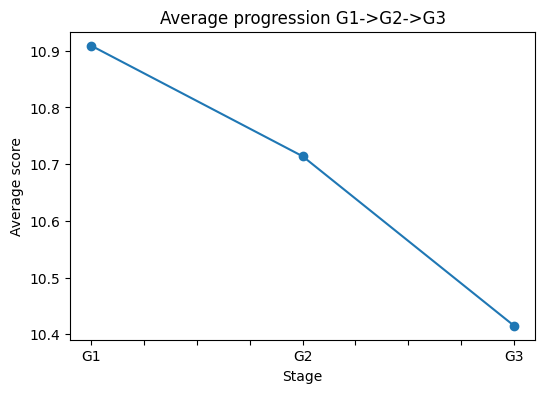

In [54]:
# 7.4 Time-series like analysis (G1->G2->G3)
# نرسم تطور كل مرحلة متوسطاً
means = df[['G1','G2','G3']].mean()
plt.figure(figsize=(6,4))
means.plot(marker='o')
plt.title('Average progression G1->G2->G3')
plt.xlabel('Stage')
plt.ylabel('Average score')
plt.show()

In [ ]:
#يحسب درجة تطور الطلاب من G1 الى لأ31
df['improve'] = df['G3'] - df['G1']
display(df.sort_values('improve', ascending=False).head(5)[['G1','G2','G3','improve']])

,G1,G2,G3,improve
4,6.0,10.0,10.0,4.0
33,8.0,10.0,12.0,4.0
40,7.0,10.0,11.0,4.0
102,10.0,13.0,14.0,4.0
96,11.0,15.0,15.0,4.0


In [56]:
# 8. توثيق وحفظ النتائج (مثال حفظ ملف)
# -------------------------
# حفظ نسخة مع النتائج (cluster, perf_cat)
df.to_csv('student_analysis_results.csv', index=False)
print("\nSaved results to student_analysis_results.csv")


Saved results to student_analysis_results.csv
